## Advanced Models, SMOTE, and SHAP Analysis

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

In [7]:
df = pd.read_csv("../data/raw/bank-additional-full.csv", sep=";")
print(df.head())
print(df.columns)

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

Features and target

In [8]:
X = df.drop("y", axis=1)
Y = df["y"].map({"no": 0, "yes": 1})

Split

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

Preprocessing

In [10]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [11]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

#### Applying SMOTE on Training Data

To address class imbalance, SMOTE is applied only to the training set. This prevents data leakage and helps the models learn minority class patterns better.

In [12]:
smote = SMOTE(random_state=42)
X_train_res, Y_train_res = smote.fit_resample(X_train_prep, Y_train)

print("Before SMOTE:")
print(Y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(Y_train_res).value_counts())

Before SMOTE:
y
0    29238
1     3712
Name: count, dtype: int64

After SMOTE:
y
0    29238
1    29238
Name: count, dtype: int64


### Advanced Models

Random Forest Classifier

In [13]:
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train_res, Y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

XG Boost

In [14]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    tree_method="hist"  # agar supported ho
)
xgb.fit(X_train_res, Y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

LightGBM

In [15]:
lgb = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1
)
lgb.fit(X_train_res, Y_train_res)

[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14831
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Catboost

In [16]:
cb = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=50,
    random_state=42
)
cb.fit(X_train_res, Y_train_res)

0:	learn: 0.5952486	total: 224ms	remaining: 44.6s
50:	learn: 0.1361337	total: 3.13s	remaining: 9.15s
100:	learn: 0.1172090	total: 6.17s	remaining: 6.05s
150:	learn: 0.1073765	total: 8.87s	remaining: 2.88s
199:	learn: 0.1000405	total: 11.5s	remaining: 0us


CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, random_state=42, verbose=50)

In [17]:
advanced_models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

adv_results = []

for name, model in advanced_models.items():
    try:
        model.fit(X_train_res, Y_train_res)
        y_pred = model.predict(X_test_prep)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_prep)[:, 1]
        else:
            y_prob = None

        adv_results.append({
            "Model": name,
            "Accuracy": accuracy_score(Y_test, y_pred),
            "Precision": precision_score(Y_test, y_pred, pos_label=1, zero_division=0),
            "Recall": recall_score(Y_test, y_pred, pos_label=1, zero_division=0),
            "F1": f1_score(Y_test, y_pred, pos_label=1, zero_division=0),
            "ROC_AUC": roc_auc_score(Y_test, y_prob) if y_prob is not None else np.nan
        })

        print(f"{name} done")

    except Exception as e:
        print(f"{name} failed:", e)

adv_results_df = pd.DataFrame(adv_results).sort_values(by="F1", ascending=False)
adv_results_df

Random Forest done
Gradient Boosting done
XGBoost done
[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14831
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ABHISHEK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ABHISHEK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM done
CatBoost done


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,LightGBM,0.922068,0.641865,0.697198,0.668388,0.954678
1,Gradient Boosting,0.899854,0.535989,0.826509,0.650276,0.948780
2,XGBoost,0.920612,0.654279,0.626078,0.639868,0.951473
4,CatBoost,0.920126,0.653061,0.620690,0.636464,0.954218
0,Random Forest,0.915028,0.629252,0.598060,0.613260,0.947278


In [18]:
print(adv_results_df.head())
best_model_name = adv_results_df.iloc[0]["Model"]
best_model_name

               Model  Accuracy  Precision    Recall        F1   ROC_AUC
3           LightGBM  0.922068   0.641865  0.697198  0.668388  0.954678
1  Gradient Boosting  0.899854   0.535989  0.826509  0.650276  0.948780
2            XGBoost  0.920612   0.654279  0.626078  0.639868  0.951473
4           CatBoost  0.920126   0.653061  0.620690  0.636464  0.954218
0      Random Forest  0.915028   0.629252  0.598060  0.613260  0.947278


'LightGBM'

In [19]:
best_model = LGBMClassifier(random_state=42)
best_model.fit(X_train_res, Y_train_res)

y_pred = best_model.predict(X_test_prep)
y_prob = best_model.predict_proba(X_test_prep)[:, 1]

[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023037 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14831
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ABHISHEK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ABHISHEK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Best model

In [20]:
from pathlib import Path
import joblib
import pandas as pd

BASE_DIR = Path.cwd()

models_dir = BASE_DIR / "models"
preprocessors_dir = BASE_DIR / "preprocessors"
outputs_dir = BASE_DIR / "outputs"

models_dir.mkdir(exist_ok=True)
preprocessors_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)

joblib.dump(best_model, models_dir / "best_model.joblib")
joblib.dump(preprocessor, preprocessors_dir / "preprocessor.joblib")

print("Model saved at:", models_dir / "best_model.joblib")
print("Preprocessor saved at:", preprocessors_dir / "preprocessor.joblib")

Model saved at: e:\GUVI ML Projects\Bank deposit prediction\notebooks\models\best_model.joblib
Preprocessor saved at: e:\GUVI ML Projects\Bank deposit prediction\notebooks\preprocessors\preprocessor.joblib


In [21]:
print(len(best_model.feature_importances_))
print(len(preprocessor.get_feature_names_out()))

63
63


In [22]:
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df.to_csv(outputs_dir / "feature_importance.csv", index=False)

feature_importance_df.head(10)

,Feature,Importance
1,num__duration,393
8,num__euribor3m,348
2,num__campaign,305
0,num__age,159
5,num__emp.var.rate,84
32,cat__education_university.degree,80
6,num__cons.price.idx,75
7,num__cons.conf.idx,72
55,cat__day_of_week_fri,71
56,cat__day_of_week_mon,69


#### Classification report

In [23]:
print(classification_report(Y_test, y_pred))
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))
print("F1:", f1_score(Y_test, y_pred))
print("ROC_AUC:", roc_auc_score(Y_test, y_prob))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7310
           1       0.64      0.70      0.67       928

    accuracy                           0.92      8238
   macro avg       0.80      0.82      0.81      8238
weighted avg       0.93      0.92      0.92      8238

Accuracy: 0.922068463219228
Precision: 0.6418650793650794
Recall: 0.697198275862069
F1: 0.6683884297520661
ROC_AUC: 0.9546775496485683


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

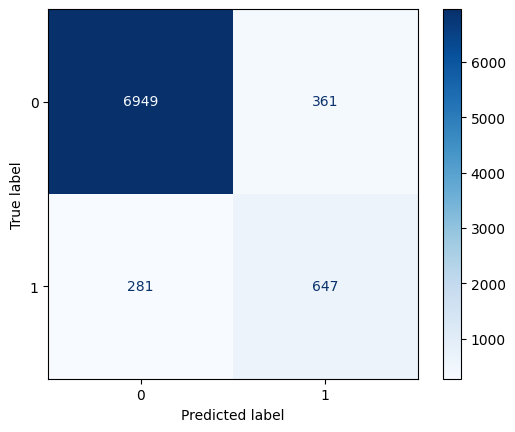

In [25]:
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [26]:
type(X_test_prep), X_test_prep.shape

(numpy.ndarray, (8238, 63))

In [27]:
X_test_prep_dense = X_test_prep.toarray() if hasattr(X_test_prep, "toarray") else X_test_prep

In [30]:
import shap

In [31]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_prep_dense)
shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

c:\Users\ABHISHEK\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


This plot shows how the most important features affect the model’s prediction in either direction.

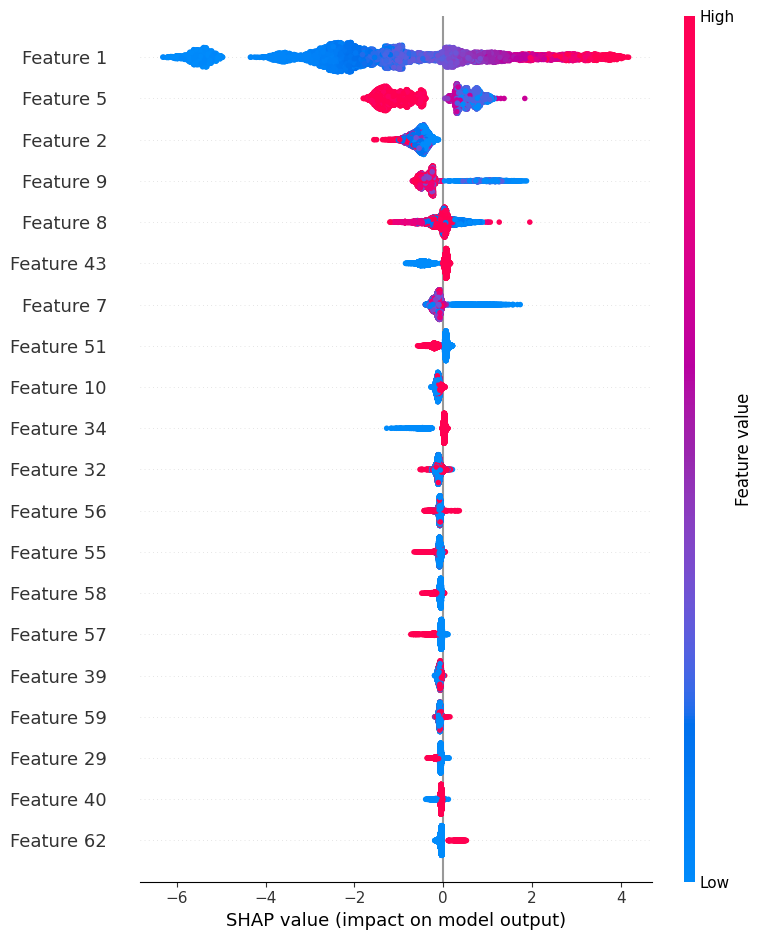

In [32]:
shap.summary_plot(shap_values_class1, X_test_prep_dense)

The SHAP summary plot shows the overall importance and direction of each feature’s contribution to the model. Features at the top have the strongest influence, while the horizontal spread shows whether high or low values push predictions toward the positive or negative class.

### LightGBM performed best overall, giving the strongest balance of F1 score and ROC-AUC.

